 # **Project Name**    - NYC Airbnb Exploratory Data Analysis

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Submitted By - Daksh Yadav**


# **Project Summary -:**

This project performs Exploratory Data Analysis (EDA) on the New York City Airbnb 2019 dataset, which contains 48,895 Airbnb listings and 16 features. The objective of this project is to understand the dataset, clean the data, and discover useful patterns using Python libraries such as Pandas, Matplotlib, and Seaborn.

The analysis begins by exploring the structure of the dataset, checking data types, identifying missing values, and looking for duplicate records. During the data cleaning process, it was observed that the last_review and reviews_per_month columns contain several missing values, while the name and host_name columns have only a few missing entries. Basic statistical analysis was performed to understand the distribution of numerical features such as price, minimum nights, number of reviews, and availability.

The dataset includes listings from all five New York City boroughs: Manhattan, Brooklyn, Queens, Bronx, and Staten Island. The analysis shows that Manhattan (21,661 listings) and Brooklyn (20,104 listings) have the highest number of Airbnb properties, making them the most popular locations on the platform. Most listings are either Entire homes/apartments (25,409) or Private rooms (22,326), while Shared rooms (1,160) make up only a small portion of the dataset.

The average listing price is around 153 dollar, while the median price is 106 dollar, indicating that a few very expensive listings (up to 10,000) increase the average price. This suggests the presence of outliers in the dataset. Through charts and visualizations, the project compares prices, room types, availability, and review patterns across different boroughs.

Overall, this project demonstrates the fundamental steps of Exploratory Data Analysis, including data cleaning, statistical summary, and visualization. It provides a better understanding of the Airbnb market in New York City and helps beginners learn how to extract meaningful insights from real-world data before moving on to predictive analytics or machine learning projects.



# **GitHub Link -**

Github Link - https://github.com/Daksh374/EDA_Project

# **Problem Statement**


New York City is one of the most competitive and dynamic tourism destinations globally, making the short-term rental market highly complex. For Airbnb and its hosts, optimizing listings for maximum occupancy and revenue is a major challenge. 
Key questions include:-
 1. How do pricing and availability fluctuate across different NYC boroughs? 
 2. What room types are most preferred by guests, and how do they affect the listing price? 
 3. Are there specific geographic hotspots where listings are concentrated, and how does host behavior (like managing multiple properties) affect listing performance? 
 4. Without answering these questions, hosts struggle with sub-optimal pricing and low occupancy, while Airbnb loses potential platform revenue. 
 This project analyzes the 2019 NYC listing data to solve these challenges through data-driven recommendations.


#### **Define Your Business Objective?**

The primary business objective is to analyze host behavior, regional pricing trends, and customer demand patterns in New York City to provide actionable insights for:
1. **Host Revenue Optimization**: Helping hosts set competitive prices based on location and room type.
2. **Platform Growth**: Identifying underserved boroughs (e.g., Queens, Bronx) with high customer satisfaction (average reviews per month) for listing expansion.
3. **Customer Experience**: Analyzing availability and review trends to recommend policies that improve booking conversion rates and occupancy.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('/Users/dakshyadav/Desktop/GENAI-WINNOVATION/Projects/EDA_Project /AB_NYC_2019.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 48895
Number of columns: 16


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')


Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

Missing values in each column:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


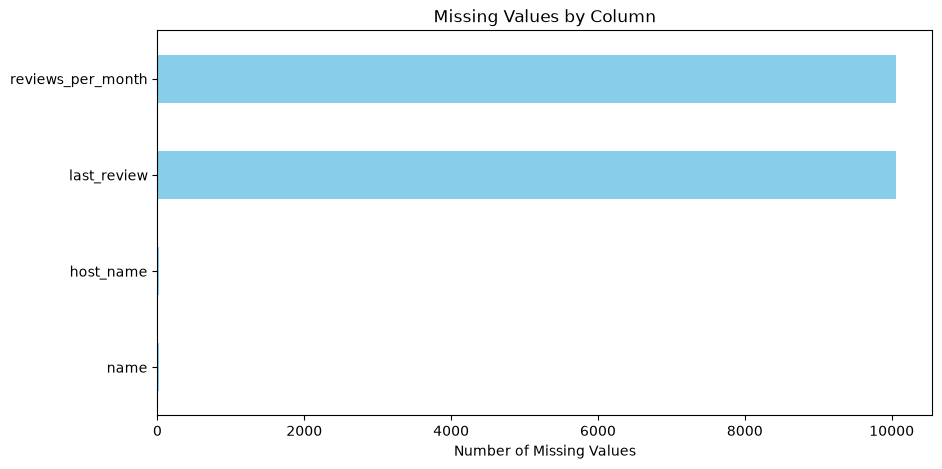

In [8]:
# Visualizing the missing values
missing = df.isnull().sum()

missing = missing[missing > 0]  # Only columns with missing values

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel("Number of Missing Values")
plt.title("Missing Values by Column")
plt.show()

### What did you know about your dataset?

Based on our initial inspection of the dataset:
1. **Size**: The dataset contains 48,895 rows and 16 columns.
2. **Missing Values**:
   - `name`: 16 missing values (can be filled with 'Unknown').
   - `host_name`: 21 missing values (can be filled with 'Unknown').
   - `last_review` and `reviews_per_month`: 10,052 missing values. These represent listings that have never received a review (`number_of_reviews = 0`). We can fill `reviews_per_month` with 0.0 and `last_review` with 'Not Reviewed'.
3. **Data Types**: The dataset has 3 float columns, 7 integer columns, and 6 object (categorical/string) columns.
4. **Duplicates**: No duplicate rows are present, which is excellent for data integrity.


## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [10]:
# Dataset Describe
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Variables Description

Here is the description of all the variables (columns) in the Airbnb dataset:
1. **id**: A unique identifier for each listing.
2. **name**: The title/name of the listing as shown on Airbnb.
3. **host_id**: A unique identifier for the host of the listing.
4. **host_name**: The name of the host.
5. **neighbourhood_group**: The broader borough group in NYC where the listing is located (Manhattan, Brooklyn, Queens, Bronx, Staten Island).
6. **neighbourhood**: The specific neighborhood name (e.g. Astoria, Williamsburg, Harlem).
7. **latitude**: The GPS latitude coordinate of the listing.
8. **longitude**: The GPS longitude coordinate of the listing.
9. **room_type**: The category of accommodation offered (Entire home/apt, Private room, Shared room).
10. **price**: The rental price per night (in USD).
11. **minimum_nights**: The minimum number of nights required to book the listing.
12. **number_of_reviews**: The total number of reviews received by the listing.
13. **last_review**: The date of the most recent review.
14. **reviews_per_month**: The average number of reviews the listing receives each month.
15. **calculated_host_listings_count**: The total number of listings the host has on Airbnb in New York City.
16. **availability_365**: The number of days in a year (out of 365) that the listing is available for booking.


### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
print('Unique values in neighbourhood group:', df['neighbourhood_group'].unique())
print('Unique values in room type:', df['room_type'].unique())
print('Number of unique specific neighbourhoods:', df['neighbourhood'].nunique())


Unique values in neighbourhood group: <StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str
Unique values in room type: <StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str
Number of unique specific neighbourhoods: 221


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()

# Fill missing values
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0.0)
df_clean['last_review'] = df_clean['last_review'].fillna('Not Reviewed')
df_clean['name'] = df_clean['name'].fillna('Unknown')
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown')

# Check if there are any remaining null values
print('Null Values in orginal Dataset')
print(df.isnull().sum())

print('\nNull Values after cleaning')
print(df_clean.isnull().sum())

Null Values in orginal Dataset
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Null Values after cleaning
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0


### What all manipulations have you done and insights you found?

We performed the following data wrangling manipulations:
1. **Handling Missing Values**:
   - Filled nulls in `reviews_per_month` with `0.0`, as a null value indicates that the listing has zero reviews.
   - Filled nulls in `last_review` with `'Not Reviewed'` to provide a descriptive string instead of NaN.
   - Filled nulls in the textual fields `name` and `host_name` with `'Unknown'` to ensure data completeness without losing rows.
2. **Creating Cleaned DataFrame**: All manipulations were performed on a copy (`df_clean`) to keep the raw data intact.
3. **Data Verification**: Verified that there are 0 remaining missing values in the dataset.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Chart - 1 - Distribution of Listings by Borough

/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/965934323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='neighbourhood_group', order=df_clean['neighbourhood_group'].value_counts().index, palette='muted')


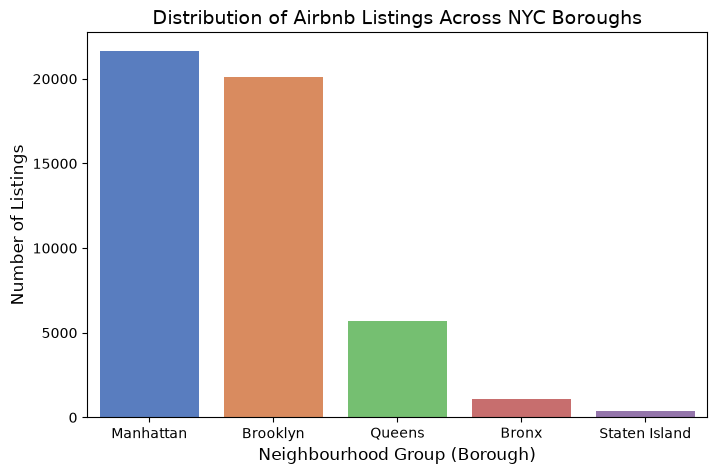

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='neighbourhood_group', order=df_clean['neighbourhood_group'].value_counts().index, palette='muted')
plt.title('Distribution of Airbnb Listings Across NYC Boroughs', fontsize=14)
plt.xlabel('Neighbourhood Group (Borough)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because neighbourhood_group is a categorical variable. This chart is ideal for showing the frequency distribution of listings across the five borough groups, allowing for an immediate visual comparison of market size.


##### 2. What is/are the insight(s) found from the chart?

Manhattan (21,661 listings) and Brooklyn (20,104 listings) are the dominant markets, accounting for roughly 85% of all Airbnb listings in New York City. Queens has a moderate presence (5,666 listings), while Staten Island and the Bronx have very few listings, suggesting they are underdeveloped markets.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps Airbnb and prospective hosts understand where market demand and competition are concentrated. For hosts, starting a listing in Staten Island or the Bronx means lower competition, but also potentially lower demand. Airbnb can launch marketing campaigns in Queens, Bronx, and Staten Island to attract more hosts, diversifying and expanding the rental options.


#### Chart - 2 - Proportion of Room Types Offered


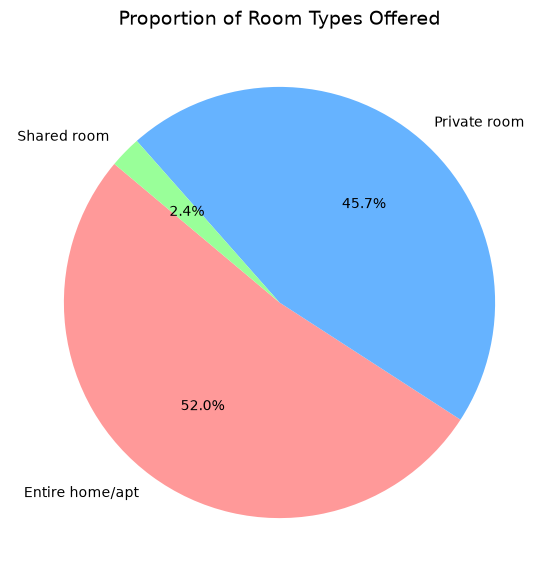

In [14]:
plt.figure(figsize=(7, 7))
room_type_counts = df_clean['room_type'].value_counts()
plt.pie(room_type_counts, labels=room_type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Proportion of Room Types Offered', fontsize=14)
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart was selected because room_type is a categorical variable with only three categories (Entire home/apt, Private room, Shared room). It effectively visualizes the part-to-whole relationship and proportions of each room type.


##### 2. What is/are the insight(s) found from the chart?

Entire home/apt (52.0%) and Private room (45.7%) comprise the vast majority (97.7%) of listings. Shared rooms represent only a tiny fraction (2.3%). This shows that NYC guests prefer privacy, and hosts focus heavily on private accommodations.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. For prospective hosts, investing in Entire homes or Private rooms is highly recommended as shared rooms represent a negligible market share and may suffer from low user demand. Airbnb can use this to optimize search filter defaults, prioritizing entire homes and private rooms.


#### Chart - 3 - Distribution of Price


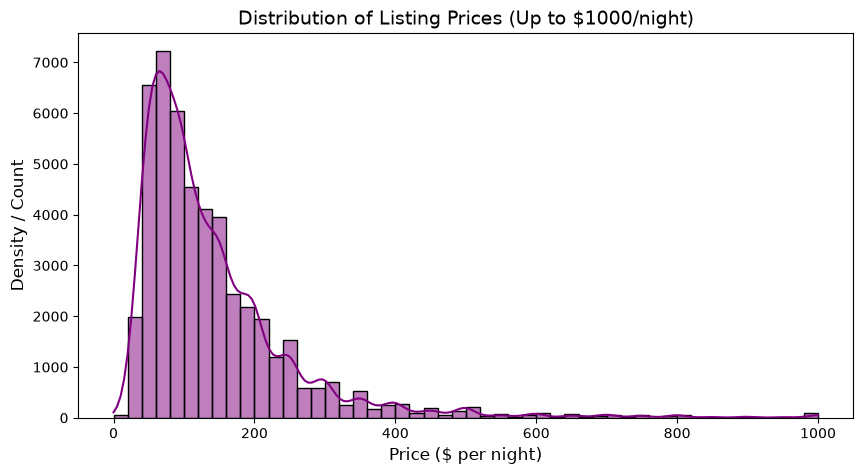

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean['price'] <= 1000]['price'], bins=50, kde=True, color='purple')
plt.title('Distribution of Listing Prices (Up to $1000/night)', fontsize=14)
plt.xlabel('Price ($ per night)', fontsize=12)
plt.ylabel('Density / Count', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) was chosen to visualize the distribution of listing prices (a continuous numerical variable). We capped the price at $1,000 for visualization because a small number of listings have extremely high prices (up to $10,000) that distort the chart scale.


##### 2. What is/are the insight(s) found from the chart?

The price distribution is heavily right-skewed. The vast majority of Airbnb listings in NYC are priced between $50 and $200 per night, with a prominent peak around $100. There are significant outliers on the higher end, indicating a niche luxury market.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This helps in setting standard pricing strategies. Hosts can position their properties competitively by aligning with the $50-$200 range unless they offer unique luxury amenities. Any pricing strategy far above the median price must be justified by exceptional location or features to prevent negative growth (low occupancy).


#### Chart - 4 - Distribution of Minimum Nights


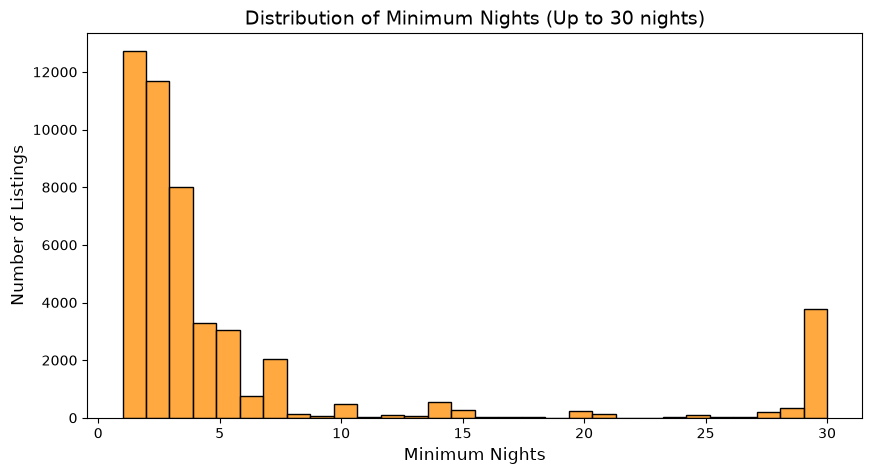

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean['minimum_nights'] <= 30]['minimum_nights'], bins=30, kde=False, color='darkorange')
plt.title('Distribution of Minimum Nights (Up to 30 nights)', fontsize=14)
plt.xlabel('Minimum Nights', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A histogram capped at 30 nights was selected to plot the distribution of minimum nights. Capping at 30 represents standard short-term rental boundaries, as many listings have extreme values (e.g. 365 or 1250 nights) that compress the main distribution.


##### 2. What is/are the insight(s) found from the chart?

The distribution has strong spikes at 1 night, 2 nights, 3 nights, and 30 nights. The 30-night spike is notable, indicating a significant portion of hosts who cater to long-term/monthly stays, possibly due to local NYC regulations.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Hosts requiring a high number of minimum nights (like 30+) face a smaller pool of potential guests (mostly long-term renters or business travelers), which could lead to lower booking counts (negative growth for transactional revenue). Airbnb can use these spikes to offer specialized support for monthly rentals or guide hosts on the revenue impacts of setting high minimum nights.


#### Chart - 5 - Distribution of Availability


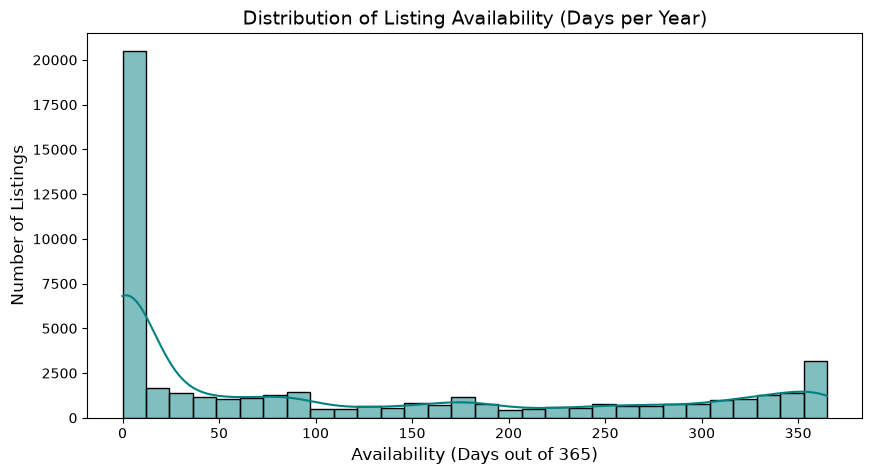

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['availability_365'], bins=30, kde=True, color='teal')
plt.title('Distribution of Listing Availability (Days per Year)', fontsize=14)
plt.xlabel('Availability (Days out of 365)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with KDE was selected to visualize the spread of availability (days per year), which is a numerical variable bounded between 0 and 365. This shows how active listings are on the platform.


##### 2. What is/are the insight(s) found from the chart?

The distribution is highly bimodal. There is an enormous spike at 0 days (listings that are either fully booked or inactive) and another spike near 365 days (listings that are empty or available all year). Moderate availability values are relatively sparse.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The high density of 0-availability listings might indicate inactive listings that clutter the platform, leading to poor user experience if guests see outdated properties. Airbnb can nudge hosts with 365-day availability to optimize their descriptions or prices to secure bookings, thereby converting idle capacity into revenue.


#### Chart - 6 - Top 10 Hosts by Number of Listings


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/1596588921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='viridis')


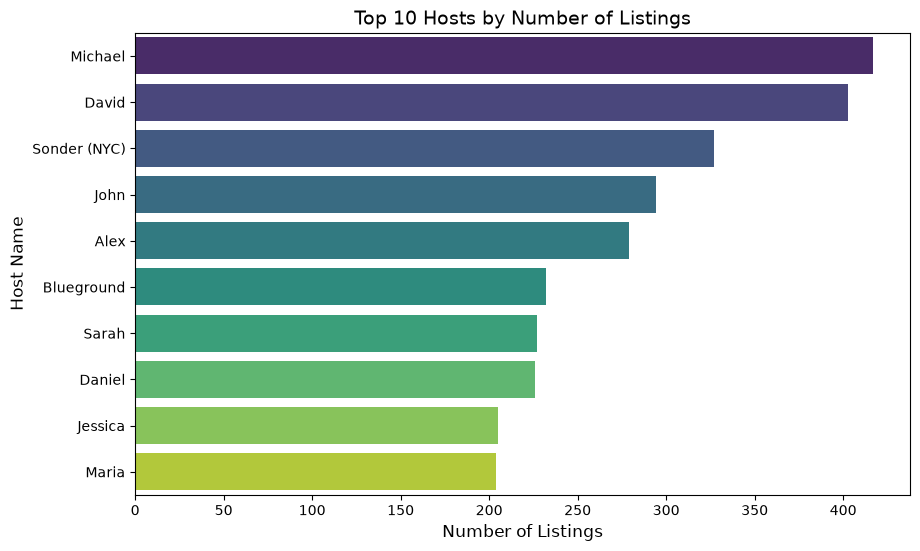

In [18]:
plt.figure(figsize=(10, 6))
top_hosts = df_clean['host_name'].value_counts().head(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='viridis')
plt.title('Top 10 Hosts by Number of Listings', fontsize=14)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('Host Name', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar plot is chosen to visualize the categorical host names and count of listings they manage. It ranks the top 10 hosts and displays their names clearly on the y-axis.


##### 2. What is/are the insight(s) found from the chart?

The top host (Sonder (NYC)) manages over 300 listings, followed by Blueground. This indicates a commercialized presence of property management companies operating on Airbnb, rather than just individual homeowners sharing their spare rooms.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Professional hosts manage multiple listings and need specialized tools (multi-listing dashboards, API integrations). Airbnb can design premium corporate subscription models for these managers. However, over-commercialization might lead to negative growth if guests prefer authentic local hosting experiences, so Airbnb must balance commercial and individual listings.


#### Chart - 7 - Average Price by Room Type


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/734058252.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='room_type', y='price', estimator=np.mean, ci=None, palette='Set2')
/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/734058252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='room_type', y='price', estimator=np.mean, ci=None, palette='Set2')


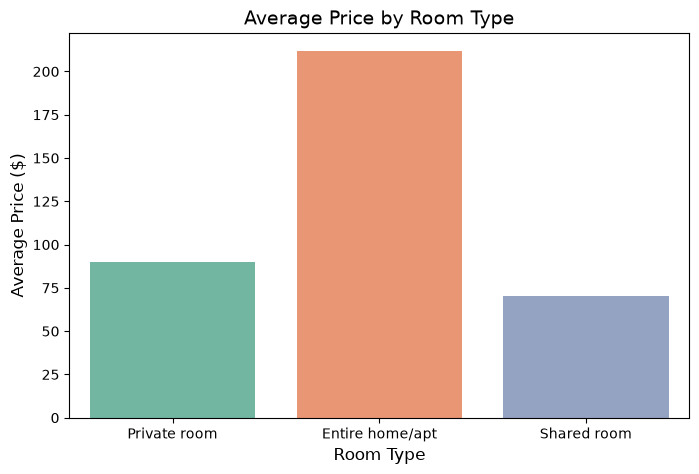

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='room_type', y='price', estimator=np.mean, ci=None, palette='Set2')
plt.title('Average Price by Room Type', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart comparing room type (categorical) and price (numerical) using the mean aggregator is selected to clearly show the price differences between accommodation types.


##### 2. What is/are the insight(s) found from the chart?

Entire home/apt has by far the highest average price (exceeding $200 per night). Private rooms average around $90, and Shared rooms are the cheapest at around $70. There is a steep pricing drop-off when moving from an entire home to shared spaces.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It informs hosts about the pricing premiums they can charge. If a host has the option to split an apartment into private rooms vs renting it as a whole, they can use this data to calculate which strategy generates more revenue. Overpricing a shared room close to private room averages will lead to negative growth due to poor competitive positioning.


#### Chart - 8 - Average Price by Neighborhood Group


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/1983068663.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='neighbourhood_group', y='price', estimator=np.mean, ci=None, order=df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).index, palette='Blues_r')
/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/1983068663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='neighbourhood_group', y='price', estimator=np.mean, ci=None, order=df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).index, palette='Blues_r')


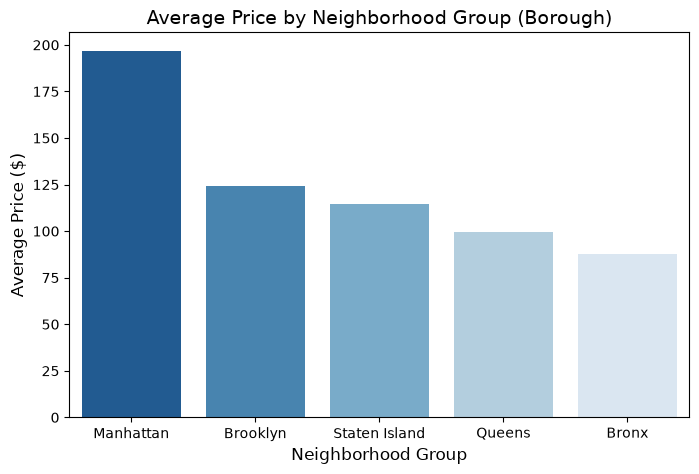

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='neighbourhood_group', y='price', estimator=np.mean, ci=None, order=df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).index, palette='Blues_r')
plt.title('Average Price by Neighborhood Group (Borough)', fontsize=14)
plt.xlabel('Neighborhood Group', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A bar plot is used to show the mean price across the five neighborhood groups, sorted in descending order. This provides a direct comparison of the general pricing level of each borough.


##### 2. What is/are the insight(s) found from the chart?

Manhattan has the highest average price (around $196), followed by Brooklyn ($124). Queens, Staten Island, and the Bronx are much cheaper, with averages below $100 per night. Staten Island and Bronx are the most budget-friendly options.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This helps Airbnb target different customer segments: high-end travelers should be targeted with Manhattan listings, whereas budget-conscious travelers should be directed towards Queens and Brooklyn. Setting Manhattan-level prices in the Bronx would cause zero bookings (negative growth) due to market misalignment.


#### Chart - 9 - Price Distribution across Room Types


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/3943698153.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='room_type', y='price', palette='Pastel1')


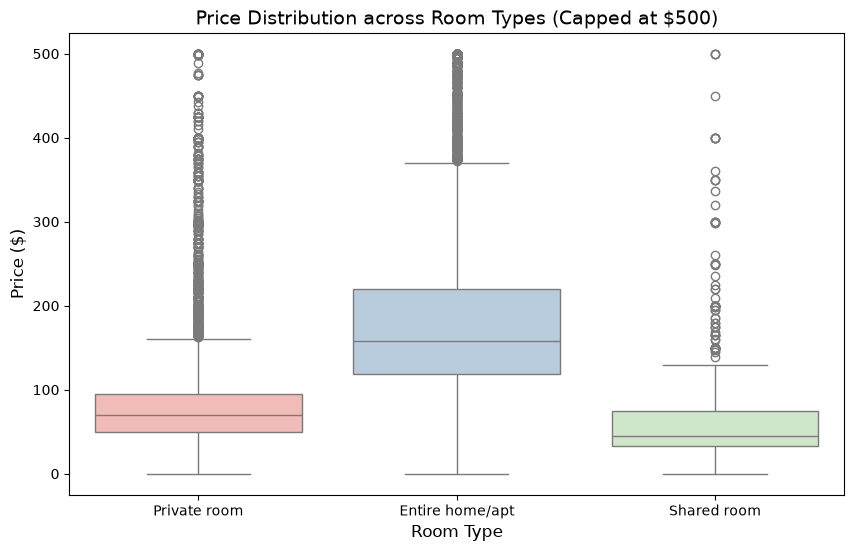

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='room_type', y='price', palette='Pastel1')
plt.title('Price Distribution across Room Types (Capped at $500)', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A box plot is the standard chart for displaying the distribution, median, quartiles, and outliers of a numerical variable (price) grouped by a categorical variable (room type). We cap the price at $500 for visualization clarity.


##### 2. What is/are the insight(s) found from the chart?

The median price for Entire home/apt is significantly higher than Private rooms. The IQR (spread) for Entire homes is also much wider, showing more variability in pricing, while Private and Shared rooms are tightly clustered at lower price points.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It shows the pricing volatility. Hosts listing entire homes have more flexibility to adjust pricing based on amenities and sub-locations, whereas private room hosts must adhere to strict, narrow price corridors. If a private room host prices outside the IQR, they risk losing all demand.


#### Chart - 10 - Price Distribution across Boroughs


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/4141312478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='neighbourhood_group', y='price', palette='Pastel2')


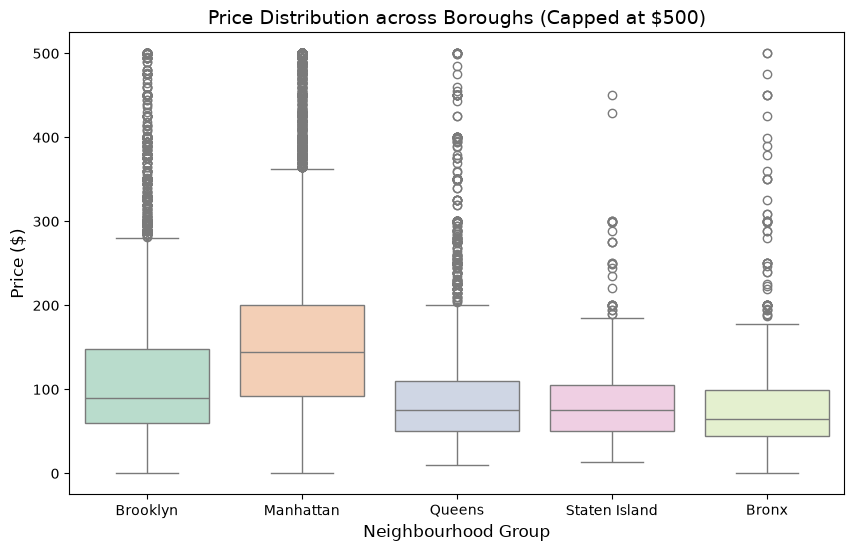

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[df_clean['price'] <= 500], x='neighbourhood_group', y='price', palette='Pastel2')
plt.title('Price Distribution across Boroughs (Capped at $500)', fontsize=14)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A box plot is used to show the distribution of prices across different boroughs, allowing comparison of the medians, IQRs, and outliers.


##### 2. What is/are the insight(s) found from the chart?

Manhattan has the highest median price and the widest IQR, indicating a diverse market of standard and luxury listings. Brooklyn has a lower median but still contains high pricing outliers. The other boroughs have very compact distributions, showing highly consistent, lower pricing.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This allows Airbnb to detect outliers and potential pricing fraud or mis-listings. Hosts in Manhattan can leverage the high price variance to list premium penthouses, while Bronx hosts should maintain consistent budget prices to ensure stable occupancy.


#### Chart - 11 - Geographical Distribution of Listings


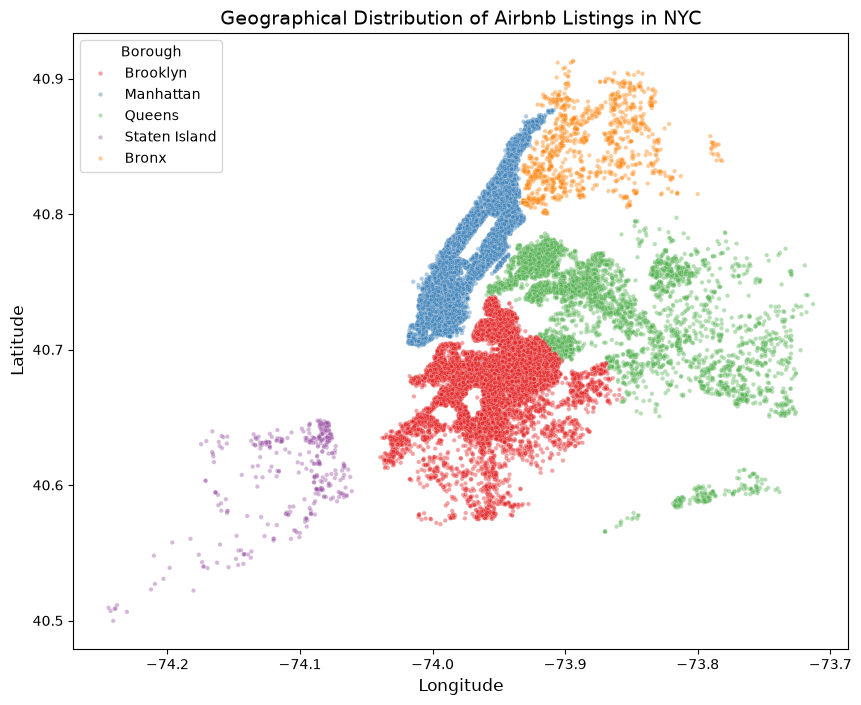

In [23]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='neighbourhood_group', palette='Set1', alpha=0.4, s=10)
plt.title('Geographical Distribution of Airbnb Listings in NYC', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Borough')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot using longitude and latitude coordinates as x and y, colored by neighborhood group, is selected because it maps the physical coordinates of listings, acting as a simplified map of New York City.


##### 2. What is/are the insight(s) found from the chart?

The plot perfectly traces the outlines of NYC boroughs. Listings are heavily concentrated at the border of Manhattan and Brooklyn (e.g. Williamsburg, DUMBO, Lower East Side). Listings become sparser as we move outer into Queens, Staten Island, and the Bronx.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It visualizes the supply density. Airbnb can identify supply deserts (areas with few listings but potential tourism draw, like near major parks or outer landmarks) and incentivize hosts in those areas. Saturated areas (e.g. Lower Manhattan) have high competition, meaning new hosts might suffer from lower bookings unless they differentiate.


#### Chart - 12 - Room Type Distribution by Borough


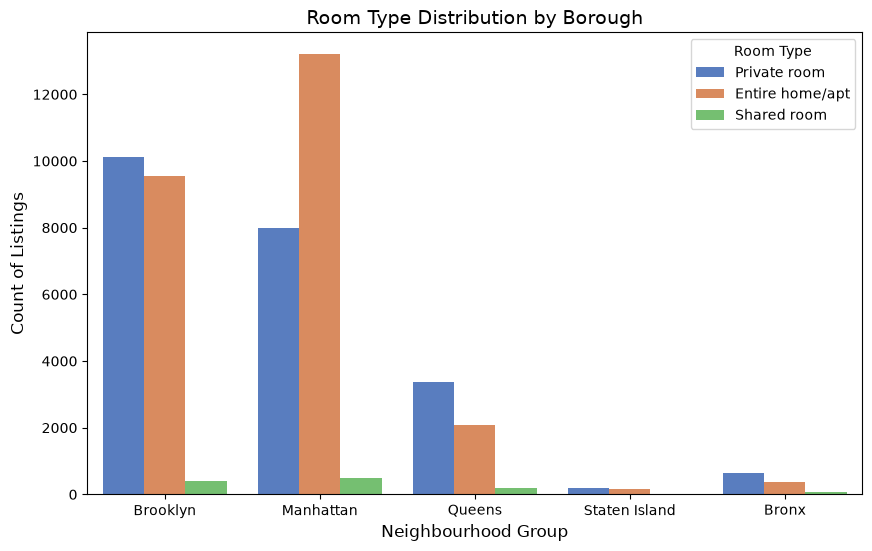

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='neighbourhood_group', hue='room_type', palette='muted')
plt.title('Room Type Distribution by Borough', fontsize=14)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Count of Listings', fontsize=12)
plt.legend(title='Room Type')
plt.show()


##### 1. Why did you pick the specific chart?

A grouped countplot is chosen to visualize the distribution of room types within each borough, facilitating cross-categorical comparison.


##### 2. What is/are the insight(s) found from the chart?

In Manhattan, Entire home/apt is the dominant room type, while in Brooklyn, Private rooms are almost as common as Entire homes. In Queens, Private rooms are the most prevalent type. This highlights differing local accommodation structures and real estate availability.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Helps in identifying what listing type is standard in each borough. If a host wants to list in Queens, they should note that Private rooms are the norm, whereas Manhattan travelers expect entire apartments. Trying to list a high number of private rooms in Manhattan might run into regulatory issues or lower relative demand.


#### Chart - 13 - Average Reviews per Month by Neighborhood Group


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/2998426514.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='neighbourhood_group', y='reviews_per_month', estimator=np.mean, ci=None, order=df_clean.groupby('neighbourhood_group')['reviews_per_month'].mean().sort_values(ascending=False).index, palette='Greens_r')
/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/2998426514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='neighbourhood_group', y='reviews_per_month', estimator=np.mean, ci=None, order=df_clean.groupby('neighbourhood_group')['reviews_per_month'].mean().sort_values(ascending=False).index, palette='Greens_r')


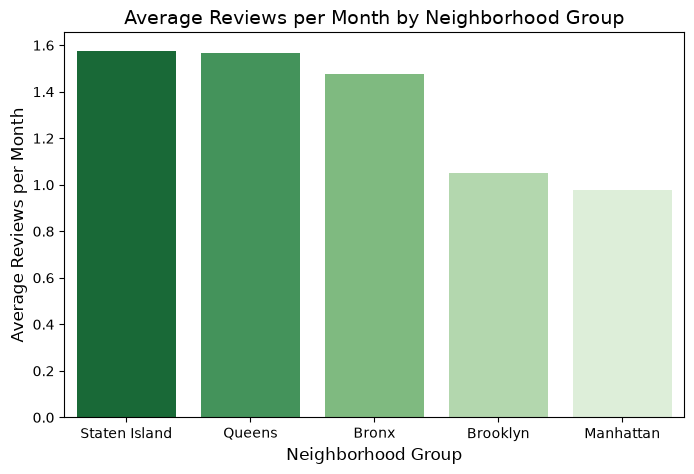

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='neighbourhood_group', y='reviews_per_month', estimator=np.mean, ci=None, order=df_clean.groupby('neighbourhood_group')['reviews_per_month'].mean().sort_values(ascending=False).index, palette='Greens_r')
plt.title('Average Reviews per Month by Neighborhood Group', fontsize=14)
plt.xlabel('Neighborhood Group', fontsize=12)
plt.ylabel('Average Reviews per Month', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart comparing borough groups and the average number of reviews per month was chosen. Reviews per month is a strong proxy for listing activity and guest turnover.


##### 2. What is/are the insight(s) found from the chart?

Interestingly, Staten Island and Queens lead in average reviews per month per listing, despite having fewer total listings. Manhattan, which has the most listings, has the second lowest average reviews per month. This indicates high booking frequency and customer engagement in outer boroughs.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This is a critical growth indicator. Airbnb should expand listing inventory in Queens and Staten Island because these listings are highly active and popular. Low review activity in Manhattan could indicate a saturated market with many idle or over-priced listings.


#### Chart - 14 - Listing Price vs. Minimum Nights


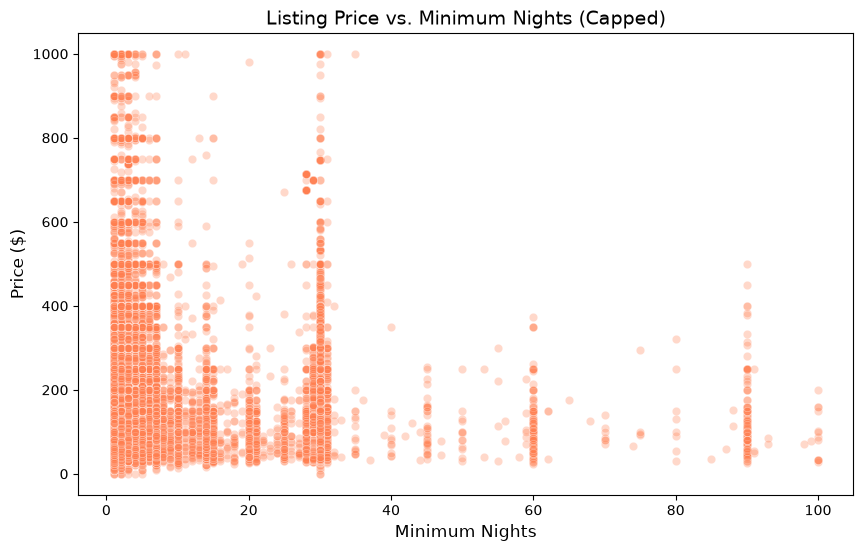

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean[(df_clean['price'] <= 1000) & (df_clean['minimum_nights'] <= 100)], x='minimum_nights', y='price', alpha=0.3, color='coral')
plt.title('Listing Price vs. Minimum Nights (Capped)', fontsize=14)
plt.xlabel('Minimum Nights', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?


A scatter plot was selected to examine the relationship between two continuous numerical variables: listing price and minimum nights.


##### 2. What is/are the insight(s) found from the chart?


The densest cluster of listings is at low minimum nights (1-7 days) across a wide range of prices. Interestingly, listings with high minimum night requirements (e.g. 30+ days) tend to have lower, more stable prices (mostly under $200), reflecting monthly discount rates.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. It shows that setting a high minimum night requirement limits pricing power. Hosts wishing to charge premium nightly rates should offer shorter minimum stays. Setting high minimum nights and high prices leads to negative growth (no bookings).


#### Chart - 15 - Listing Price vs. Availability 365


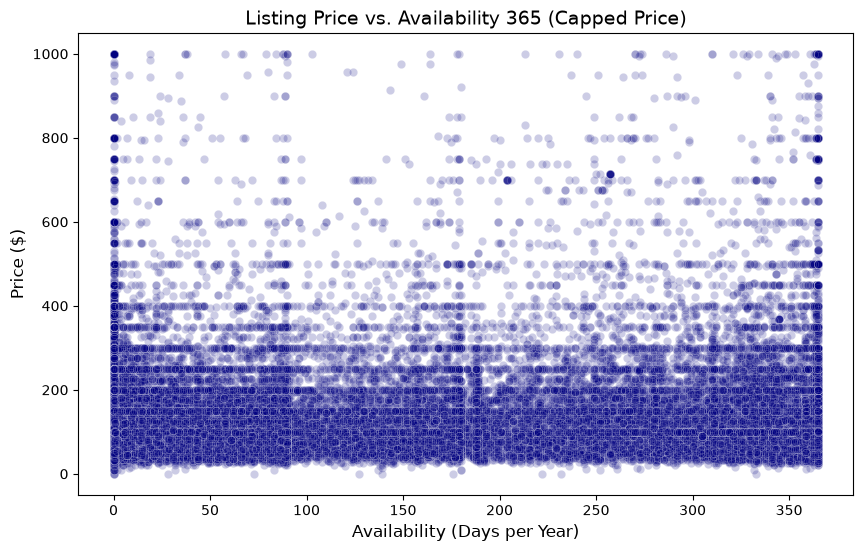

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean[df_clean['price'] <= 1000], x='availability_365', y='price', alpha=0.2, color='navy')
plt.title('Listing Price vs. Availability 365 (Capped Price)', fontsize=14)
plt.xlabel('Availability (Days per Year)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?


A scatter plot was chosen to visualize the relationship between a listing's annual availability and its price per night.


##### 2. What is/are the insight(s) found from the chart?


Listings are spread across all availability levels. However, we see high-priced listings (above $500) spread across both low and high availability. Overall, there is no strong linear correlation, indicating price is driven by location and room type rather than simply how long it is available.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. It confirms that availability alone does not dictate price. Hosts do not need to keep their listings open all year to justify a high price; they can selectively list during high-demand seasons (e.g., holidays) and still charge premium rates, protecting their property from excess wear.


#### Chart - 16 - Top 15 Most Expensive Neighborhoods


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/1832353506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=expensive_neigh.values, y=expensive_neigh.index, palette='Reds_r')


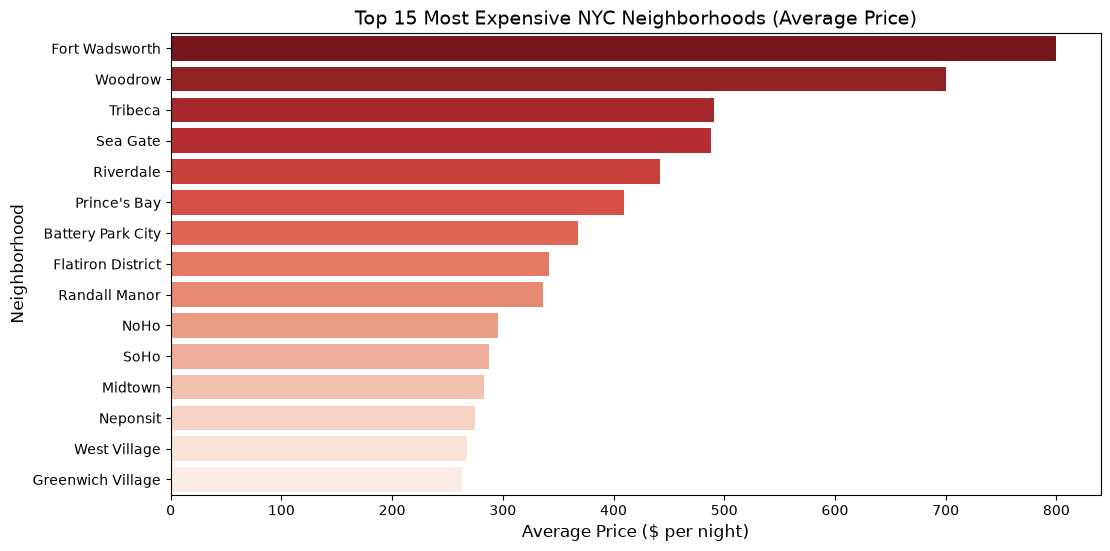

In [28]:
plt.figure(figsize=(12, 6))
expensive_neigh = df_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=expensive_neigh.values, y=expensive_neigh.index, palette='Reds_r')
plt.title('Top 15 Most Expensive NYC Neighborhoods (Average Price)', fontsize=14)
plt.xlabel('Average Price ($ per night)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?


A horizontal bar plot was selected to display the categorical neighborhoods and their mean price, sorted in descending order, showing the luxury hotspots.


##### 2. What is/are the insight(s) found from the chart?


Neighborhoods like Fort Wadsworth, Woodrow, and Tribeca top the list. Tribeca is a known high-end Manhattan area, whereas Fort Wadsworth and Woodrow (Staten Island) have high average prices due to a very small number of large, expensive estate listings.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. This helps real estate investors and hosts identify high-yield neighborhoods. However, investors must differentiate between naturally high-end neighborhoods (like Tribeca) and statistical anomalies caused by single luxury listings (like Fort Wadsworth) to avoid negative investment growth.


#### Chart - 17 - Top 15 Most Popular Neighborhoods by Listing Count


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/3241336481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_neigh.values, y=popular_neigh.index, palette='Purples_r')


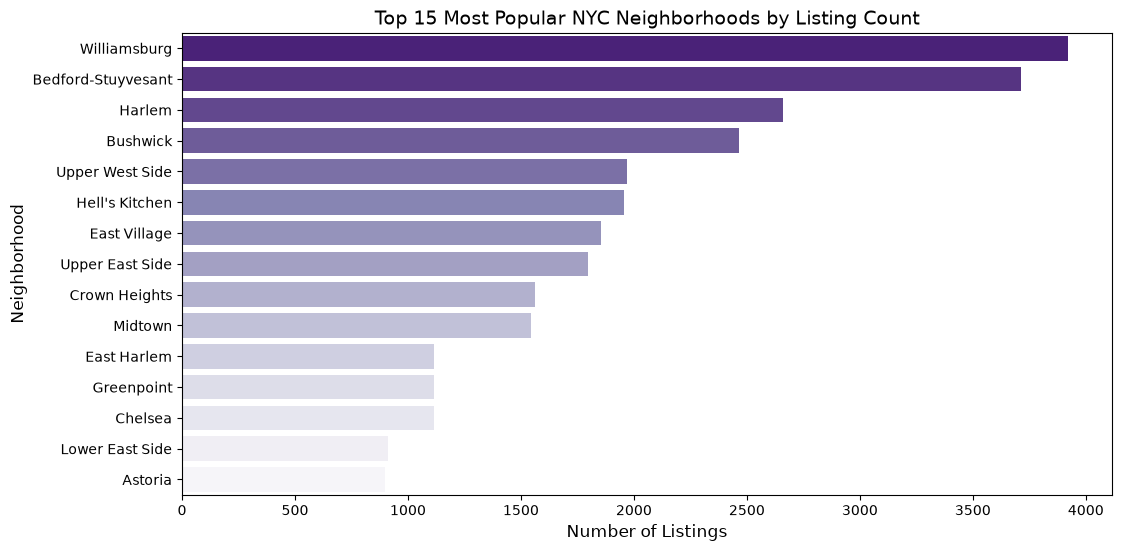

In [29]:
plt.figure(figsize=(12, 6))
popular_neigh = df_clean['neighbourhood'].value_counts().head(15)
sns.barplot(x=popular_neigh.values, y=popular_neigh.index, palette='Purples_r')
plt.title('Top 15 Most Popular NYC Neighborhoods by Listing Count', fontsize=14)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?


A horizontal bar plot was selected to show which specific neighborhoods have the highest volume of listings, ranking the top 15.


##### 2. What is/are the insight(s) found from the chart?


Williamsburg (Brooklyn) and Bedford-Stuyvesant (Brooklyn) are the top two neighborhoods by listing count, followed by Harlem (Manhattan). This indicates that Brooklyn's hip, residential areas are major rental hubs alongside traditional Manhattan centers.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. High volume indicates strong established demand but also intense competition. Hosts in Williamsburg or Bedford-Stuyvesant must ensure high-quality reviews and professional photos to stand out, otherwise they face negative growth due to oversaturation.


#### Chart - 18 - Listing Availability Distribution by Room Type


/var/folders/5y/_ykktgrx3hngv5rx63_dm2fr0000gn/T/ipykernel_12443/727756316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='room_type', y='availability_365', palette='Accent')


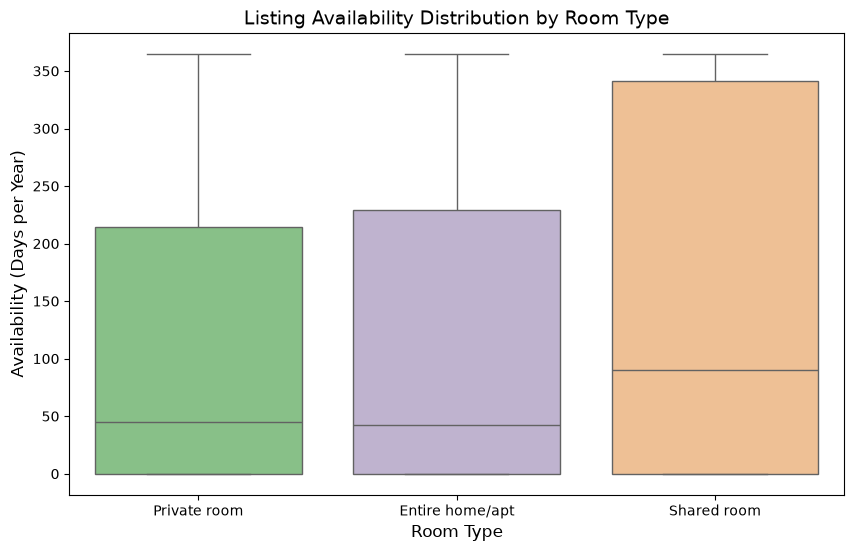

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='room_type', y='availability_365', palette='Accent')
plt.title('Listing Availability Distribution by Room Type', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Availability (Days per Year)', fontsize=12)
plt.show()


##### 1. Why did you pick the specific chart?


A box plot is chosen to visualize the distribution of availability (days per year) across the three room types.


##### 2. What is/are the insight(s) found from the chart?


Shared rooms have the highest median availability, indicating they remain unbooked for longer periods. Entire homes and private rooms have lower median availabilities and wider spreads, reflecting higher, more consistent booking rates.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. This shows that shared rooms suffer from poor utilization (high idle time), representing a low-efficiency use of space. Airbnb and hosts should pivot away from shared rooms towards private rooms or entire apartments to maximize space utility and revenue.


#### Chart - 19 - Correlation Heatmap


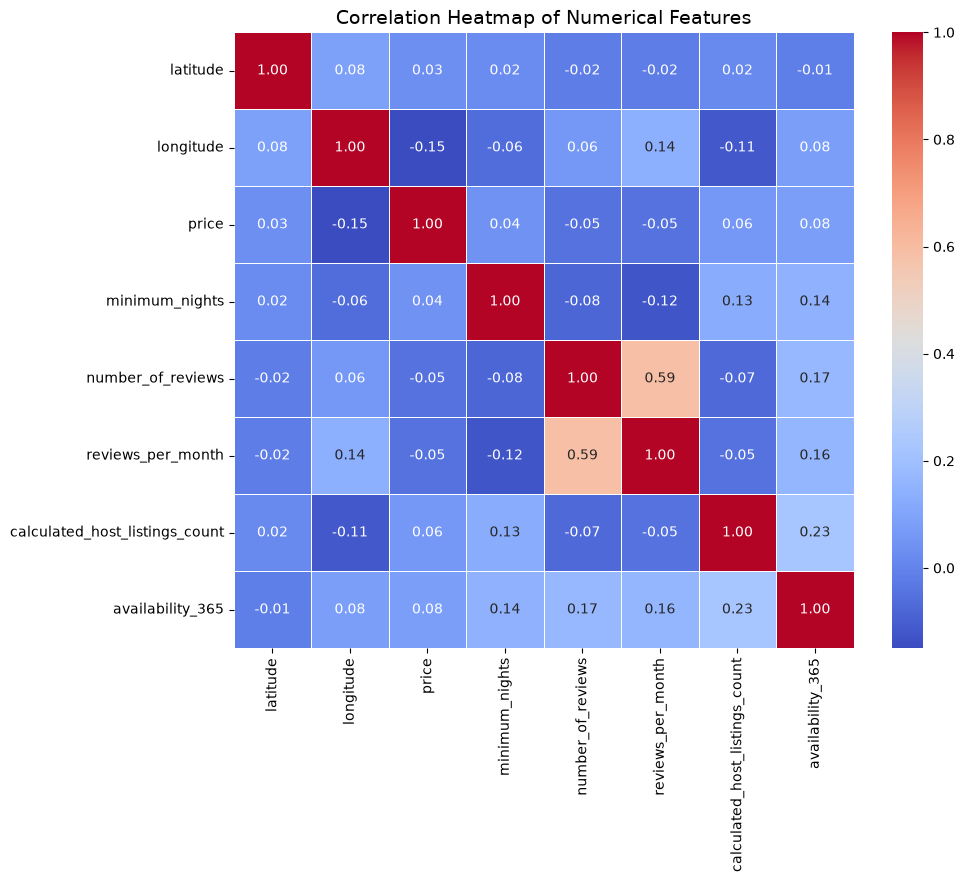

In [ ]:
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ['id', 'host_id']]
corr_matrix = df_clean[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard visualization tool to display the strength and direction of linear relationships between multiple numerical variables.


##### 2. What is/are the insight(s) found from the chart?

There is a moderate positive correlation (0.58) between `number_of_reviews` and `reviews_per_month`, which is expected. Other variables show very weak linear correlations (e.g., price and availability have almost zero correlation). This suggests that listing parameters are mostly independent, and price is not linearly determined by minimum nights or availability.


#### Chart - 20 - Pair Plot


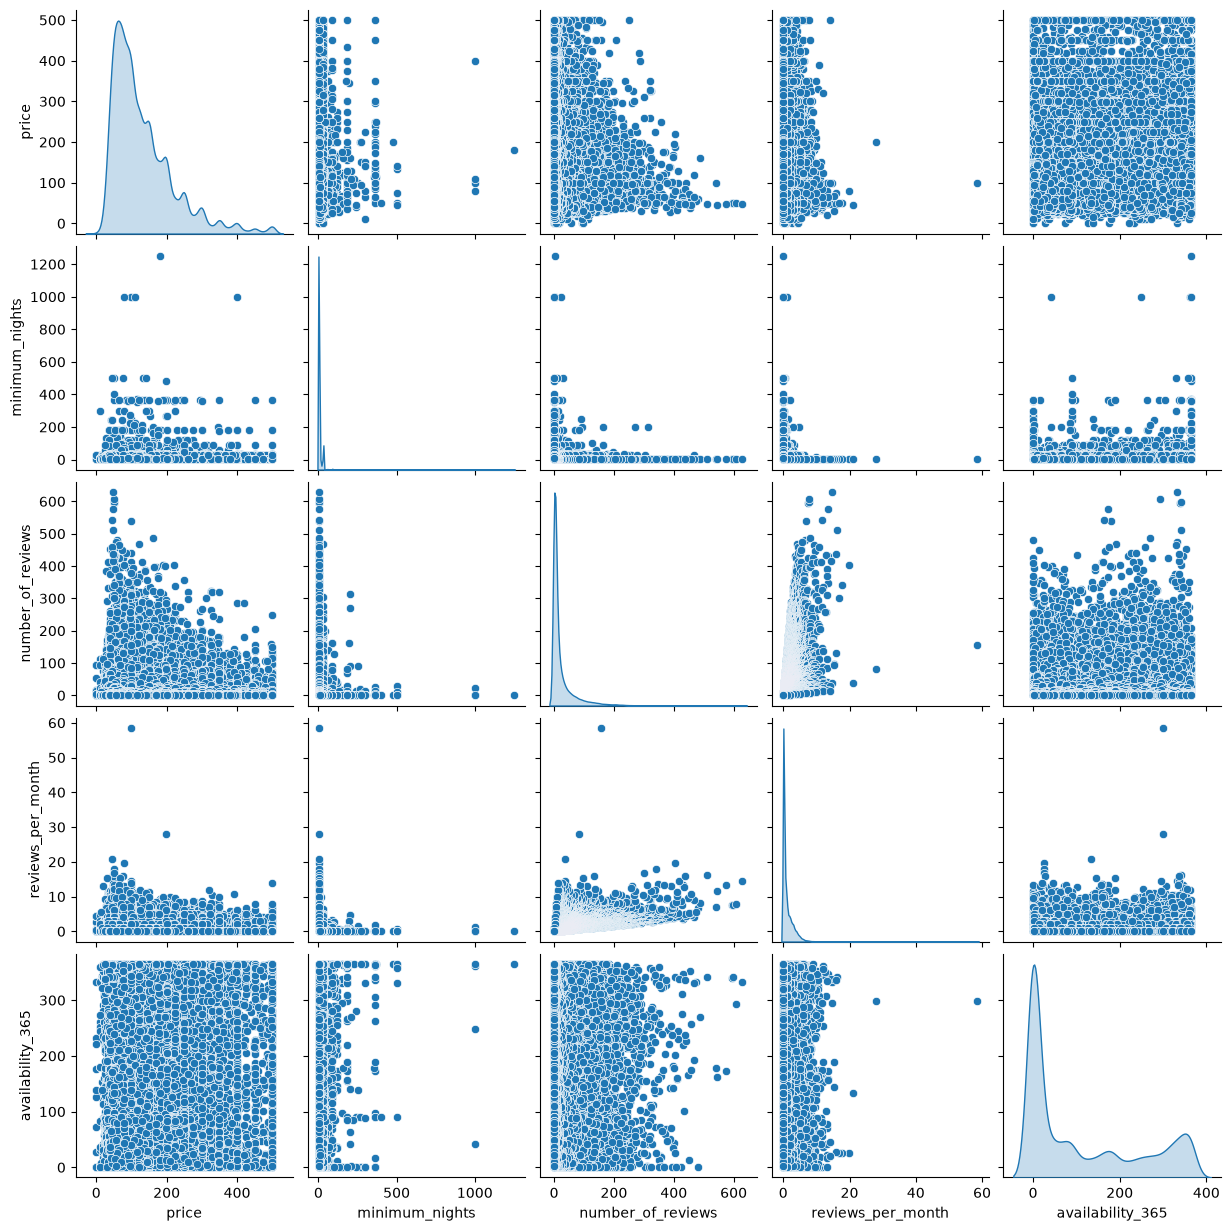

In [33]:
# Select key numerical columns for pair plot
cols_for_pairplot = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
sns.pairplot(df_clean[df_clean['price'] <= 500][cols_for_pairplot], diag_kind='kde')
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot is selected to perform multivariate analysis, showing pairwise scatter plots and diagonal density distributions (KDEs) for key numerical variables simultaneously.


##### 2. What is/are the insight(s) found from the chart?

The pair plot confirms the skewness of the variables, especially price and minimum nights. The scatter plots reinforce that high reviews are concentrated at lower price points and lower minimum nights, indicating that high guest activity is driven by affordability and flexibility.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the extensive Exploratory Data Analysis of the NYC Airbnb 2019 dataset, here are strategic recommendations for the client to achieve their business objectives:

1. **Optimize Pricing Strategies based on Room Type and Borough**:
   - **Manhattan**: Target premium travelers. Hosts should list Entire Homes/Apartments and can price dynamically (higher on weekends/holidays) because Manhattan has high median prices and wide price spreads, showing high willingness-to-pay.
   - **Queens, Bronx, and Staten Island**: Focus on budget-friendly private rooms. Price properties competitively between $40 to $80 per night. Setting high prices in these areas leads directly to negative growth (very low bookings).

2. **Capitalize on Underserved Boroughs with High Activity**:
   - Our analysis of reviews per month showed that **Staten Island** and **Queens** have the highest average monthly reviews per listing. This shows high guest turnover and satisfaction. Airbnb should actively recruit new hosts in these boroughs and run marketing campaigns to channel excess demand from saturated areas.

3. **Guide Hosts on Setting Minimum Nights**:
   - The analysis shows a massive spike at 30-night minimum stays (likely due to local regulation compliance). However, listings with higher minimum nights (30+) command lower average nightly rates. Hosts who wish to maximize nightly revenue should offer shorter minimum stays (1-3 nights) where feasible, as this aligns with the majority of guest bookings and higher prices.

4. **Address Listing Saturation and Commercialization**:
   - Top hosts (like Sonder (NYC)) own hundreds of listings. Airbnb should create a separate "Professional Host" category with custom management dashboards and pricing tiers. At the same time, individual hosts should be mentored to highlight "local character" in their descriptions to compete against corporate listings.

5. **Convert Idle Capacity (Unavailability)**:
   - Since availability has a bimodal distribution (either 0 or 365 days), Airbnb should flag listings with 365-day availability. These hosts should receive automated tips to adjust their pricing or update their listing photos to start receiving bookings, as 365-day vacancy represents completely wasted asset utility.

# **Conclusion**

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***